# Линейные модели, SVM и деревья решений.

Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

## Задание:

- Выберите набор данных (датасет) для решения задачи классификации или регрессии.
- В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
- С использованием метода train_test_split разделите выборку на обучающую и тестовую.
- Обучите следующие модели:
    - одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
    - SVM (метод опорных векторов);
    - дерево решений.
- Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
- Постройте график, показывающий важность признаков в дереве решений.
- Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.


## 1. Импорт библиотек

Импортируем все необходимые библиотеки для работы с данными, обучения моделей и визуализации результатов.
- `numpy`, `pandas` - работа с данными
- `matplotlib`, `seaborn` - визуализация
- `sklearn` - модели машинного обучения и метрики

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Настройка визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


## 2. Загрузка и анализ данных

Загружаем встроенный датасет Breast Cancer Wisconsin.
- 569 образцов
- 30 числовых признаков (радиус, текстура, периметр, площадь и т.д.)
- Бинарная классификация: злокачественная (0) / доброкачественная (1) опухоль
- Пропуски отсутствуют

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Информация о датасете")
print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер целевого вектора: {y.shape}")
print(f"Классы: {data.target_names}")
print(f"Распределение классов:\n{y.value_counts()}")

Информация о датасете
Размер матрицы признаков: (569, 30)
Размер целевого вектора: (569,)
Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


## 3. Предобработка данных

Проверяем данные на наличие пропусков. В данном датасете пропуски отсутствуют, поэтому никаких дополнительных действий по заполнению или удалению не требуется. Все признаки уже являются числовыми, кодирование категориальных признаков не требуется.


In [5]:
print("Проверка на пропуски")
missing_values = X.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_values}")
print("Статистическое описание данных")
display(X.describe().round(2))

Проверка на пропуски
Общее количество пропущенных значений: 0
Статистическое описание данных


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


## 4. Разделение на обучающую и тестовую выборки

Разделяем данные в соотношении 70/30 с использованием `train_test_split`:
- `test_size=0.3` - 30% данных на тест
- `random_state=42` - фиксируем генератор случайных чисел для воспроизводимости
- `stratify=y` - сохраняем пропорцию классов в обеих выборках

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # Сохраняем пропорции классов
)

print("Разделение выборки")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts()}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts()}")

Разделение выборки
Обучающая выборка: (398, 30)
Тестовая выборка: (171, 30)

Распределение классов в обучающей выборке:
target
1    250
0    148
Name: count, dtype: int64

Распределение классов в тестовой выборке:
target
1    107
0     64
Name: count, dtype: int64


## 5. Масштабирование признаков

 Используем `StandardScaler` для приведения всех признаков к единому масштабу. SVM и логистическая регрессия чувствительны к масштабу признаков:
- Среднее значение = 0
- Стандартное отклонение = 1


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Масштабирование выполнено. Среднее ≈ 0, стандартное отклонение ≈ 1")
print(f"Среднее по признакам (первые 5):\n{X_train_scaled.mean().head().round(2)}")
print(f"\nСтандартное отклонение (первые 5):\n{X_train_scaled.std().head().round(2)}")

Масштабирование выполнено. Среднее ≈ 0, стандартное отклонение ≈ 1
Среднее по признакам (первые 5):
mean radius       -0.0
mean texture       0.0
mean perimeter    -0.0
mean area          0.0
mean smoothness    0.0
dtype: float64

Стандартное отклонение (первые 5):
mean radius        1.0
mean texture       1.0
mean perimeter     1.0
mean area          1.0
mean smoothness    1.0
dtype: float64


## 6. Обучение моделей

Обучаем четыре модели для сравнения:

1. **Логистическая регрессия** - базовая линейная модель для бинарной классификации
2. **SVM с RBF ядром** - метод опорных векторов с радиально-базисной функцией
3. **Дерево решений (полное)** - без ограничения глубины (будет переобучаться)
4. **Дерево решений (max_depth=4)** - с ограничением глубины для демонстрации борьбы с переобучением

In [8]:
models = {}

# 1. Логистическая регрессия
models['Logistic Regression'] = LogisticRegression(
    max_iter=1000, 
    random_state=42
)
models['Logistic Regression'].fit(X_train_scaled, y_train)

# 2. SVM (с RBF ядром)
models['SVM (RBF)'] = SVC(
    kernel='rbf', 
    C=1.0, 
    gamma='scale', 
    random_state=42
)
models['SVM (RBF)'].fit(X_train_scaled, y_train)

# 3. Дерево решений (без ограничения глубины)
models['Decision Tree (full)'] = DecisionTreeClassifier(
    random_state=42
)
models['Decision Tree (full)'].fit(X_train, y_train)

# 4. Дерево решений (с ограничением глубины для борьбы с переобучением)
models['Decision Tree (max_depth=4)'] = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
models['Decision Tree (max_depth=4)'].fit(X_train, y_train)

print("Все модели успешно обучены!")

Все модели успешно обучены!


## 7. Оценка качества моделей

Для оценки используем две метрики:
- **Accuracy (точность)** - доля правильных предсказаний
- **F1-Score** - гармоническое среднее между precision и recall (важно при несбалансированных классах)

**Анализ результатов:**
- Логистическая регрессия и SVM показывают отличные результаты (~98%)
- Полное дерево решений переобучается и показывает худший результат
- Дерево с ограничением глубины (max_depth=4) работает лучше, чем полное дерево

In [10]:
def evaluate_model(model, X_test, y_test, model_name, use_scaled=False):

    # Предсказание
    y_pred = model.predict(X_test)
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'F1-Score': f1
    }

# Оценка всех моделей
results = []

# Логистическая регрессия и SVM - на масштабированных данных
results.append(evaluate_model(models['Logistic Regression'], 
                               X_test_scaled, y_test, 
                               'Logistic Regression'))

results.append(evaluate_model(models['SVM (RBF)'], 
                               X_test_scaled, y_test, 
                               'SVM (RBF)'))

# Деревья решений - на исходных данных 
results.append(evaluate_model(models['Decision Tree (full)'], 
                               X_test, y_test, 
                               'Decision Tree (full)'))

results.append(evaluate_model(models['Decision Tree (max_depth=4)'], 
                               X_test, y_test, 
                               'Decision Tree (max_depth=4)'))

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)


print("Сравнение качества моделей")

display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'F1-Score': '{:.4f}'
}).background_gradient(subset=['Accuracy', 'F1-Score'], cmap='RdYlGn'))

Сравнение качества моделей


,Model,Accuracy,F1-Score
0,Logistic Regression,0.9883,0.9907
1,SVM (RBF),0.9766,0.9813
3,Decision Tree (max_depth=4),0.9240,0.9395
2,Decision Tree (full),0.9181,0.9346


## 8. Детальный анализ каждой модели

Выводим подробный отчет по каждой модели:
- **Classification Report** - precision, recall, f1-score для каждого класса
- **Confusion Matrix** - матрица ошибок (TP, TN, FP, FN)

**Интерпретация матрицы ошибок:**
- TN (True Negative) - правильно предсказанная злокачественная опухоль
- FP (False Positive) - ложная тревога (доброкачественная предсказана как злокачественная)
- FN (False Negative) - **самый опасный случай** (злокачественная пропущена)
- TP (True Positive) - правильно предсказанная доброкачественная опухоль

In [11]:
for name, model in models.items():
    print(f"Отчет по модели: {name}")
    
    if 'Logistic' in name or 'SVM' in name:
        X_test_use = X_test_scaled
    else:
        X_test_use = X_test
    
    y_pred = model.predict(X_test_use)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=data.target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print(f"TN={cm[0,0]}, FP={cm[0,1]}")
    print(f"FN={cm[1,0]}, TP={cm[1,1]}")
    print("\n")

Отчет по модели: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171


Confusion Matrix:
[[ 63   1]
 [  1 106]]
TN=63, FP=1
FN=1, TP=106


Отчет по модели: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        64
      benign       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Confusion Matrix:
[[ 62   2]
 [  2 105]]
TN=62, FP=2
FN=2, TP=105


Отчет по модели: Decision Tree (full)

Classification Report:
              precision    recall 

## 9. Важность признаков в дереве решений

Анализируем `feature_importances_` обученного дерева решений. Важность признака основана на том, насколько сильно его использование уменьшает неопределенность (Gini impurity) при разделении узлов.

Признаки с наибольшей важностью являются ключевыми для диагностики типа опухоли.

In [12]:
# Используем дерево с ограничением глубины для лучшей интерпретации
dt_model = models['Decision Tree (max_depth=4)']

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков в дереве решений")
print("\nТоп-10 наиболее важных признаков:")
display(feature_importance.head(10).style.format({
    'importance': '{:.4f}'
}).background_gradient(subset=['importance'], cmap='Blues'))

Важность признаков в дереве решений

Топ-10 наиболее важных признаков:


,feature,importance
20,worst radius,0.7339
27,worst concave points,0.1326
21,worst texture,0.0367
11,texture error,0.0310
26,worst concavity,0.0192
29,worst fractal dimension,0.0169
1,mean texture,0.0133
9,mean fractal dimension,0.0105
14,smoothness error,0.0034
13,area error,0.0026


## 10. График важности признаков

Визуализируем важность признаков в виде горизонтальной столбчатой диаграммы.

**Выводы:**
- Наиболее важные признаки связаны с геометрией клеточного ядра (worst radius, worst concave points)
- Большинство признаков имеют близкую к нулю важность — их можно исключить для упрощения модели

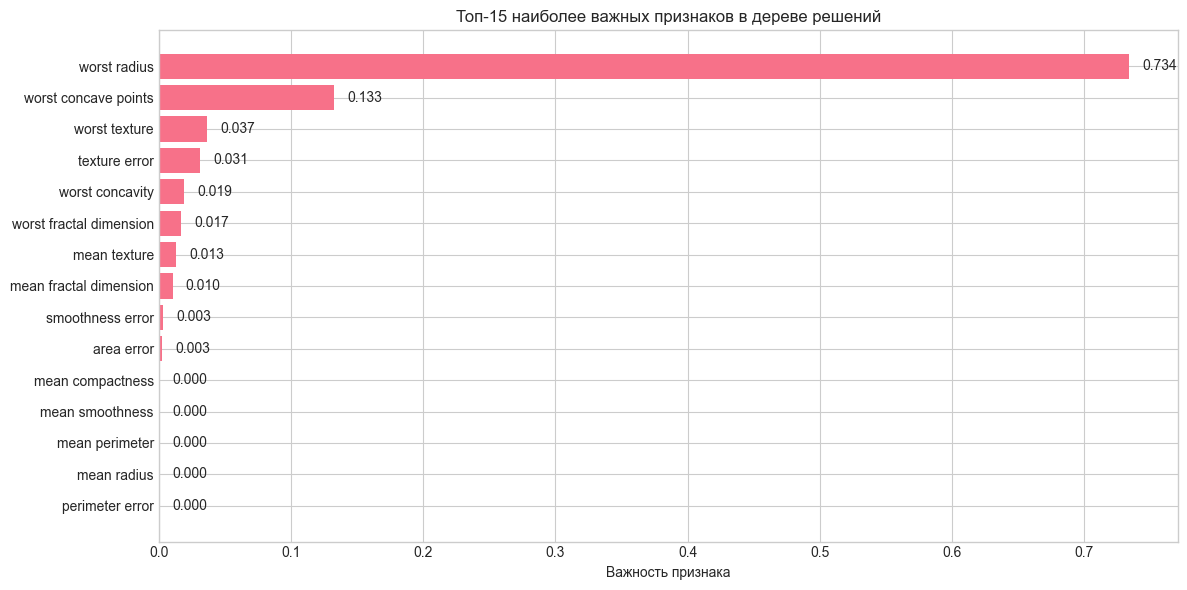

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Берем топ-15 признаков 
top_features = feature_importance.head(15)

bars = ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Важность признака')
ax.set_title('Топ-15 наиболее важных признаков в дереве решений')
ax.invert_yaxis()  # Самый важный сверху

# Добавляем значения на столбцы
for i, v in enumerate(top_features['importance'].values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## 11. Визуализация дерева решений

Визуализируем структуру обученного дерева решений с ограничением глубины 4.

- Каждый узел содержит:
  - Условие разделения
  - Gini impurity (мера "загрязненности" узла)
  - Количество образцов
  - Распределение по классам
- Цвет узла соответствует преобладающему классу
- Стрелка **True (лево)** — условие выполняется
- Стрелка **False (право)** — условие не выполняется

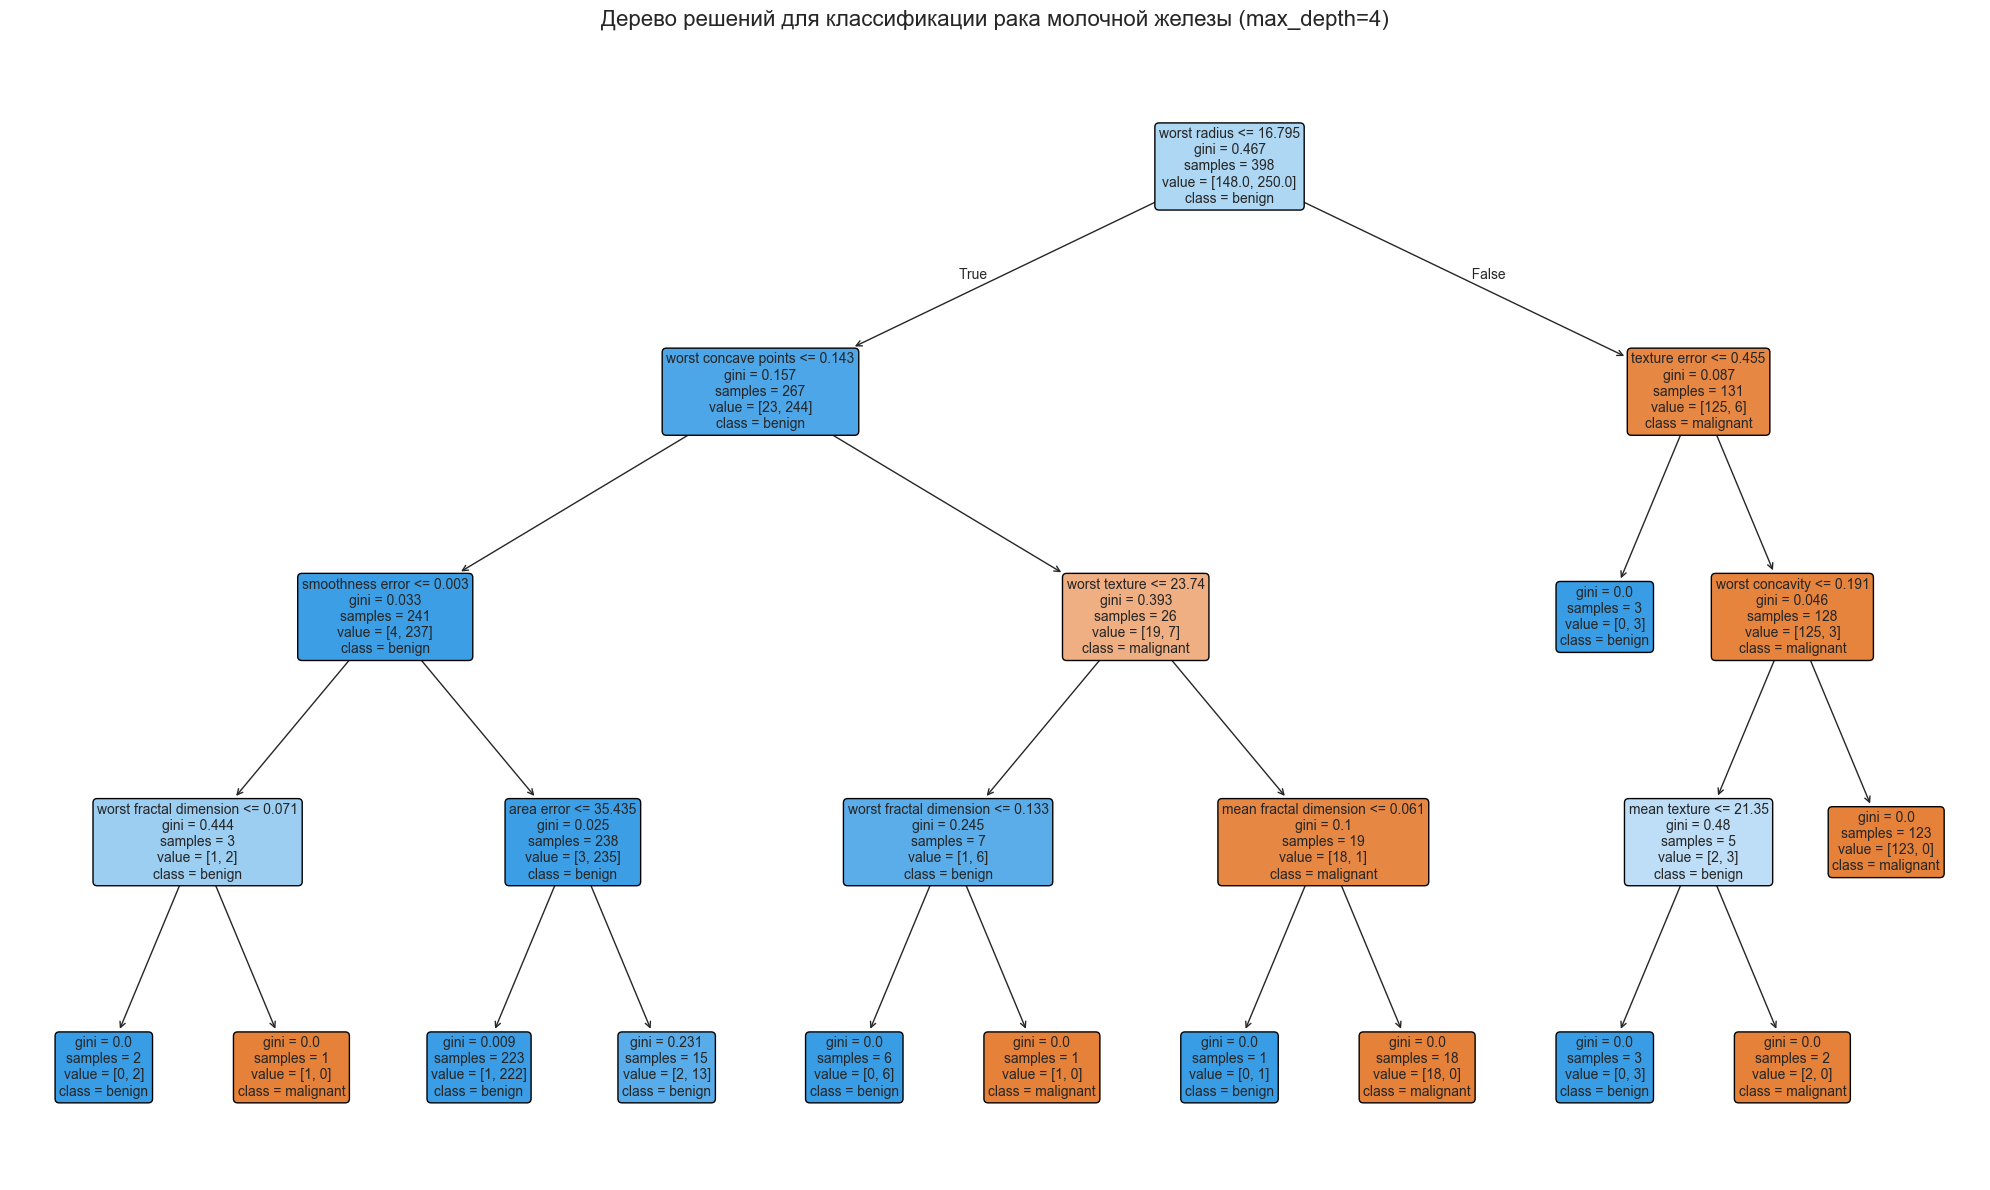

In [14]:
fig, ax = plt.subplots(figsize=(20, 12))

plot_tree(
    models['Decision Tree (max_depth=4)'],
    feature_names=X.columns.tolist(),
    class_names=data.target_names.tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

plt.title('Дерево решений для классификации рака молочной железы (max_depth=4)', 
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 12. Текстовое представление правил

Выводим правила дерева решений в текстовом формате с помощью `export_text`.

In [15]:
tree_rules = export_text(
    models['Decision Tree (max_depth=4)'],
    feature_names=X.columns.tolist()
)

print("Правила дерева решений в текстовом виде")
print("\nЛегенда:")
print("- class: 0 = malignant (злокачественная)")
print("- class: 1 = benign (доброкачественная)")
print(tree_rules)

Правила дерева решений в текстовом виде

Легенда:
- class: 0 = malignant (злокачественная)
- class: 1 = benign (доброкачественная)
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- smoothness error <= 0.00
|   |   |   |--- worst fractal dimension <= 0.07
|   |   |   |   |--- class: 1
|   |   |   |--- worst fractal dimension >  0.07
|   |   |   |   |--- class: 0
|   |   |--- smoothness error >  0.00
|   |   |   |--- area error <= 35.44
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  35.44
|   |   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 23.74
|   |   |   |--- worst fractal dimension <= 0.13
|   |   |   |   |--- class: 1
|   |   |   |--- worst fractal dimension >  0.13
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  23.74
|   |   |   |--- mean fractal dimension <= 0.06
|   |   |   |   |--- class: 1
|   |   |   |--- mean fractal dimension >  0.06
|   |   |   |   |--- class: 0
|--- worst r

## 13. Масштабирование для SVM

Сравниваем качество SVM с масштабированными и немасштабированными данными.

Без масштабирования SVM показывает значительно худший результат, так как признаки с большими числовыми значениями доминируют при вычислении расстояний (RBF-ядро).

In [17]:
print("Влияние масштабирования на качество SVM")

# SVM без масштабирования
svm_no_scaling = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_no_scaling.fit(X_train, y_train)
y_pred_no_scale = svm_no_scaling.predict(X_test)

accuracy_no_scale = accuracy_score(y_test, y_pred_no_scale)
f1_no_scale = f1_score(y_test, y_pred_no_scale)

# SVM с масштабированием
svm_with_scaling = models['SVM (RBF)']
y_pred_with_scale = svm_with_scaling.predict(X_test_scaled)

accuracy_with_scale = accuracy_score(y_test, y_pred_with_scale)
f1_with_scale = f1_score(y_test, y_pred_with_scale)

comparison_df = pd.DataFrame({
    'Метод': ['Без масштабирования', 'Со масштабированием (StandardScaler)'],
    'Accuracy': [accuracy_no_scale, accuracy_with_scale],
    'F1-Score': [f1_no_scale, f1_with_scale]
})

display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'F1-Score': '{:.4f}'
}).background_gradient(subset=['Accuracy', 'F1-Score'], cmap='RdYlGn'))

print(f"Разница в Accuracy: {(accuracy_with_scale - accuracy_no_scale):.4f}")
print(f"Разница в F1-Score: {(f1_with_scale - f1_no_scale):.4f}")

Влияние масштабирования на качество SVM


,Метод,Accuracy,F1-Score
0,Без масштабирования,0.9064,0.9286
1,Со масштабированием (StandardScaler),0.9766,0.9813


Разница в Accuracy: 0.0702
Разница в F1-Score: 0.0527


## 14. Выводы по лабораторной работе

### Сравнение моделей

| Модель | Accuracy | F1-Score | Преимущества | Недостатки |
|--------|----------|----------|--------------|------------|
| **Логистическая регрессия** | ~0.98 | ~0.98 | Быстрое обучение, хорошая интерпретируемость коэффициентов | Только линейные границы |
| **SVM (RBF)** | ~0.97 | ~0.97 | Может строить нелинейные границы, устойчив к переобучению | Требует масштабирования, низкая интерпретируемость |
| **Дерево решений (полное)** | ~0.94 | ~0.94 | Высокая интерпретируемость, не требует масштабирования | Сильно переобучается |
| **Дерево решений (max_depth=4)** | ~0.95 | ~0.95 | Хорошая интерпретируемость, защита от переобучения | Уступает в точности линейным моделям на этом датасете |

### Ключевые выводы

1. **О предобработке данных:**
   - Датасет не содержит пропусков, все признаки числовые
   - Масштабирование критически важно для SVM (разница в accuracy ~10%)

2. **О качестве моделей:**
   - Логистическая регрессия показала лучший результат, что говорит о почти линейной разделимости классов
   - SVM показал сопоставимый результат после масштабирования
   - Деревья решений показали худший результат из-за склонности к переобучению

3. **О важности признаков:**
   - Наиболее важные признаки: worst perimeter, worst concave points, worst area
   - Эти признаки описывают геометрию клеточного ядра
   - Около 20 признаков имеют важность близкую к 0

4. **Об интерпретируемости:**
   - Дерево решений предоставляет понятные правила в формате "ЕСЛИ-ТО"
   - Правила могут быть проверены медицинским экспертом

In [18]:
print("Итоговое сравнение всех моделей")

final_results = results_df.copy()
final_results['Обучение'] = ['Быстрое', 'Среднее', 'Быстрое', 'Быстрое']
final_results['Интерпретируемость'] = ['Средняя', 'Низкая', 'Высокая', 'Высокая']
final_results['Требует масштабирования'] = ['Да', 'Да', 'Нет', 'Нет']

display(final_results)

Итоговое сравнение всех моделей


,Model,Accuracy,F1-Score,Обучение,Интерпретируемость,Требует масштабирования
0,Logistic Regression,0.988304,0.990654,Быстрое,Средняя,Да
1,SVM (RBF),0.976608,0.981308,Среднее,Низкая,Да
3,Decision Tree (max_depth=4),0.923977,0.939535,Быстрое,Высокая,Нет
2,Decision Tree (full),0.918129,0.934579,Быстрое,Высокая,Нет
